# 01 — Exploratory Data Analysis: IEEE-CIS Fraud Detection

**Purpose:** Understand the dataset structure, distributions, and fraud patterns to drive feature engineering and modeling decisions.

**Dataset:** Vesta Corporation transaction records (IEEE-CIS Kaggle competition)  
**Size:** 590,540 transactions × 434 features (transaction + identity merged)  
**Target:** `isFraud` — binary classification

---

## Notebook Structure

| Section | Content | Saved figure |
|---|---|---|
| 1 | Dataset overview & column groups | — |
| 2 | Missing values analysis | `02_missing/` |
| 3 | Target variable analysis | `01_target/` |
| 4 | Transaction amount analysis | `03_amount/` |
| 5 | Temporal patterns | `04_temporal/` |
| 6 | Card features | `05_card/` |
| 7 | Email domain risk | `06_email/` |
| 8 | Browser & device | `07_browser_device/` |
| 9 | C, D, M, V columns | `08_c_d_v_m/` |
| 10 | Identity features | `09_identity/` |
| 11 | EDA conclusions & pipeline constants | `10_conclusions/` |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT_DIR = Path(r'C:\Users\sharg\Desktop\github\FinRiskGuard')
RAW_DIR  = ROOT_DIR / 'data' / 'raw' / 'ieee_cis'
FIG_DIR  = ROOT_DIR / 'outputs' / 'figures' / 'fraud' / 'eda'

SUBDIRS = [
    '01_target', '02_missing', '03_amount', '04_temporal',
    '05_card', '06_email', '07_browser_device',
    '08_c_d_v_m', '09_identity', '10_conclusions',
]
for sub in SUBDIRS:
    (FIG_DIR / sub).mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize']    = (14, 6)
plt.rcParams['font.size']         = 12
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi']        = 120

PALETTE = {
    'fraud'    : '#E24B4A',
    'legit'    : '#378ADD',
    'neutral'  : '#888780',
    'highlight': '#BA7517',
}

print(f'ROOT : {ROOT_DIR}')
print(f'RAW  : {RAW_DIR}')
print(f'FIGS : {FIG_DIR}')
print(f'Output subfolders created: {len(SUBDIRS)}')

ROOT : C:\Users\sharg\Desktop\github\FinRiskGuard
RAW  : C:\Users\sharg\Desktop\github\FinRiskGuard\data\raw\ieee_cis
FIGS : C:\Users\sharg\Desktop\github\FinRiskGuard\outputs\figures\fraud\eda
Output subfolders created: 10


---
## 1. Data Load & Overview

In [2]:
print('Loading train_transaction.csv ...')
txn = pd.read_csv(RAW_DIR / 'train_transaction.csv')
print(f'  transaction shape : {txn.shape}')

print('Loading train_identity.csv ...')
idn = pd.read_csv(RAW_DIR / 'train_identity.csv')
print(f'  identity shape    : {idn.shape}')

df = txn.merge(idn, on='TransactionID', how='left')

print(f'\n{"="*45}')
print(f'  Merged shape  : {df.shape}')
print(f'  Memory usage  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'  Fraud rate    : {df["isFraud"].mean()*100:.2f}%')
print(f'  Total fraud   : {df["isFraud"].sum():,}')
print(f'  Total legit   : {(df["isFraud"]==0).sum():,}')
print(f'  Imbalance     : {(df["isFraud"]==0).sum() / df["isFraud"].sum():.1f}:1')
print(f'{"="*45}')

print('\nColumn type distribution:')
print(df.dtypes.value_counts())

print('\nColumn groups:')
groups = {
    'Transaction meta': ['TransactionID','TransactionDT','TransactionAmt','ProductCD'],
    'Card features'   : [c for c in df.columns if c.startswith('card')],
    'Address'         : [c for c in df.columns if c.startswith('addr')],
    'Email'           : [c for c in df.columns if 'email' in c.lower()],
    'C columns'       : [c for c in df.columns if c.startswith('C') and c[1:].isdigit()],
    'D columns'       : [c for c in df.columns if c.startswith('D') and c[1:].isdigit()],
    'M columns'       : [c for c in df.columns if c.startswith('M') and c[1:].isdigit()],
    'V columns'       : [c for c in df.columns if c.startswith('V') and c[1:].isdigit()],
    'Identity id_'    : [c for c in df.columns if c.startswith('id_')],
    'Device'          : [c for c in df.columns if 'device' in c.lower()],
}
for name, cols in groups.items():
    print(f'  {name:<20} : {len(cols):>3} columns')

fraud = df[df['isFraud'] == 1]
legit = df[df['isFraud'] == 0]

Loading train_transaction.csv ...
  transaction shape : (590540, 394)
Loading train_identity.csv ...
  identity shape    : (144233, 41)

  Merged shape  : (590540, 434)
  Memory usage  : 1984.2 MB
  Fraud rate    : 3.50%
  Total fraud   : 20,663
  Total legit   : 569,877
  Imbalance     : 27.6:1

Column type distribution:
float64    399
str         31
int64        4
Name: count, dtype: int64

Column groups:
  Transaction meta     :   4 columns
  Card features        :   6 columns
  Address              :   2 columns
  Email                :   2 columns
  C columns            :  14 columns
  D columns            :  15 columns
  M columns            :   9 columns
  V columns            : 339 columns
  Identity id_         :  38 columns
  Device               :   2 columns


---
## 2. Missing Values Analysis

Missing value patterns inform two key pipeline decisions:
1. **Drop threshold** — columns >90% missing carry no signal and are dropped
2. **NaN flags** — for informative columns (especially D columns), NaN itself is a predictive signal

> **Saved:** `outputs/figures/fraud/eda/02_missing/missing_overview.png`

MISSING VALUES SUMMARY
  Columns with any missing   : 414
  Columns >90% missing       : 12
  Columns >50% missing       : 214
  Columns >20% missing       : 252

Top 20 most missing:
       missing_count  missing_pct
id_24         585793    99.196159
id_25         585408    99.130965
id_07         585385    99.127070
id_08         585385    99.127070
id_21         585381    99.126393
id_26         585377    99.125715
id_27         585371    99.124699
id_23         585371    99.124699
id_22         585371    99.124699
dist2         552913    93.628374
D7            551623    93.409930
id_18         545427    92.360721
D13           528588    89.509263
D14           528353    89.469469
D12           525823    89.041047
id_03         524216    88.768923
id_04         524216    88.768923
D6            517353    87.606767
id_33         517251    87.589494
id_10         515614    87.312290

Missing by column group:
  C columns       | avg:   0.0% | max:   0.0% | zero missing:  14/14
  D col

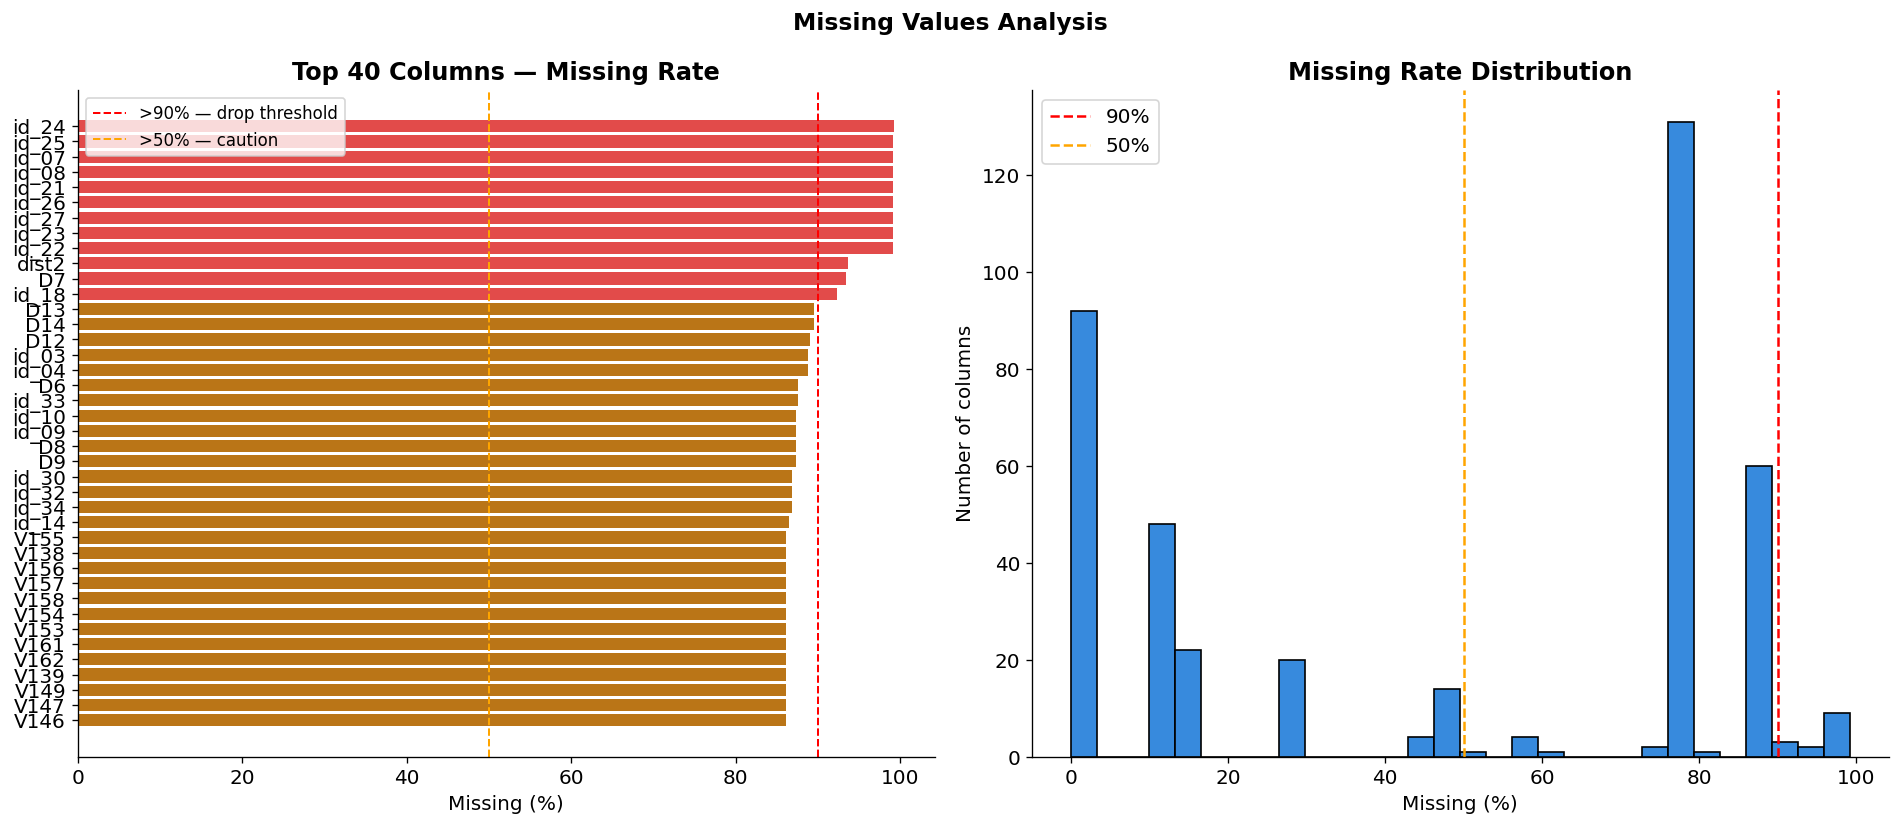

Saved: 02_missing/missing_overview.png


In [3]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct'  : df.isnull().mean() * 100,
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print('='*50)
print('MISSING VALUES SUMMARY')
print('='*50)
print(f'  Columns with any missing   : {len(missing)}')
print(f'  Columns >90% missing       : {(missing["missing_pct"] > 90).sum()}')
print(f'  Columns >50% missing       : {(missing["missing_pct"] > 50).sum()}')
print(f'  Columns >20% missing       : {(missing["missing_pct"] > 20).sum()}')

print(f'\nTop 20 most missing:')
print(missing.head(20).to_string())

print('\nMissing by column group:')
miss_groups = {
    'C columns'   : [c for c in df.columns if c.startswith('C') and c[1:].isdigit()],
    'D columns'   : [c for c in df.columns if c.startswith('D') and c[1:].isdigit()],
    'M columns'   : [c for c in df.columns if c.startswith('M') and c[1:].isdigit()],
    'V columns'   : [c for c in df.columns if c.startswith('V') and c[1:].isdigit()],
    'Identity id_': [c for c in df.columns if c.startswith('id_')],
}
for name, cols in miss_groups.items():
    if not cols: continue
    grp = df[cols].isnull().mean() * 100
    print(f'  {name:<15} | avg: {grp.mean():5.1f}% | max: {grp.max():5.1f}% | zero missing: {(grp==0).sum():>3}/{len(cols)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top40 = missing.head(40)
axes[0].barh(
    top40.index[::-1], top40['missing_pct'][::-1],
    color=[PALETTE['fraud'] if x > 90 else PALETTE['highlight'] if x > 50 else PALETTE['legit']
           for x in top40['missing_pct'][::-1]]
)
axes[0].axvline(90, color='red',    ls='--', lw=1.2, label='>90% — drop threshold')
axes[0].axvline(50, color='orange', ls='--', lw=1.2, label='>50% — caution')
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Top 40 Columns — Missing Rate', fontweight='bold')
axes[0].legend(fontsize=10)

axes[1].hist(missing['missing_pct'], bins=30, color=PALETTE['legit'], edgecolor='black')
axes[1].axvline(90, color='red',    ls='--', lw=1.5, label='90%')
axes[1].axvline(50, color='orange', ls='--', lw=1.5, label='50%')
axes[1].set_xlabel('Missing (%)')
axes[1].set_ylabel('Number of columns')
axes[1].set_title('Missing Rate Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle('Missing Values Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_missing' / 'missing_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_missing/missing_overview.png')

---
## 3. Target Variable Analysis

Understanding class imbalance is critical for model training strategy.

**Key finding:** 27.6:1 imbalance requires explicit handling:
- XGBoost → `scale_pos_weight = 28`
- LightGBM → `is_unbalance = True`
- CatBoost → `auto_class_weights = 'Balanced'`

> **Saved:** `outputs/figures/fraud/eda/01_target/target_analysis.png`

TARGET VARIABLE — isFraud
  Legit (0)       : 569,877  (96.50%)
  Fraud (1)       :  20,663  (3.50%)
  Imbalance ratio : 27.6 : 1
  scale_pos_weight: 28  (for XGBoost)


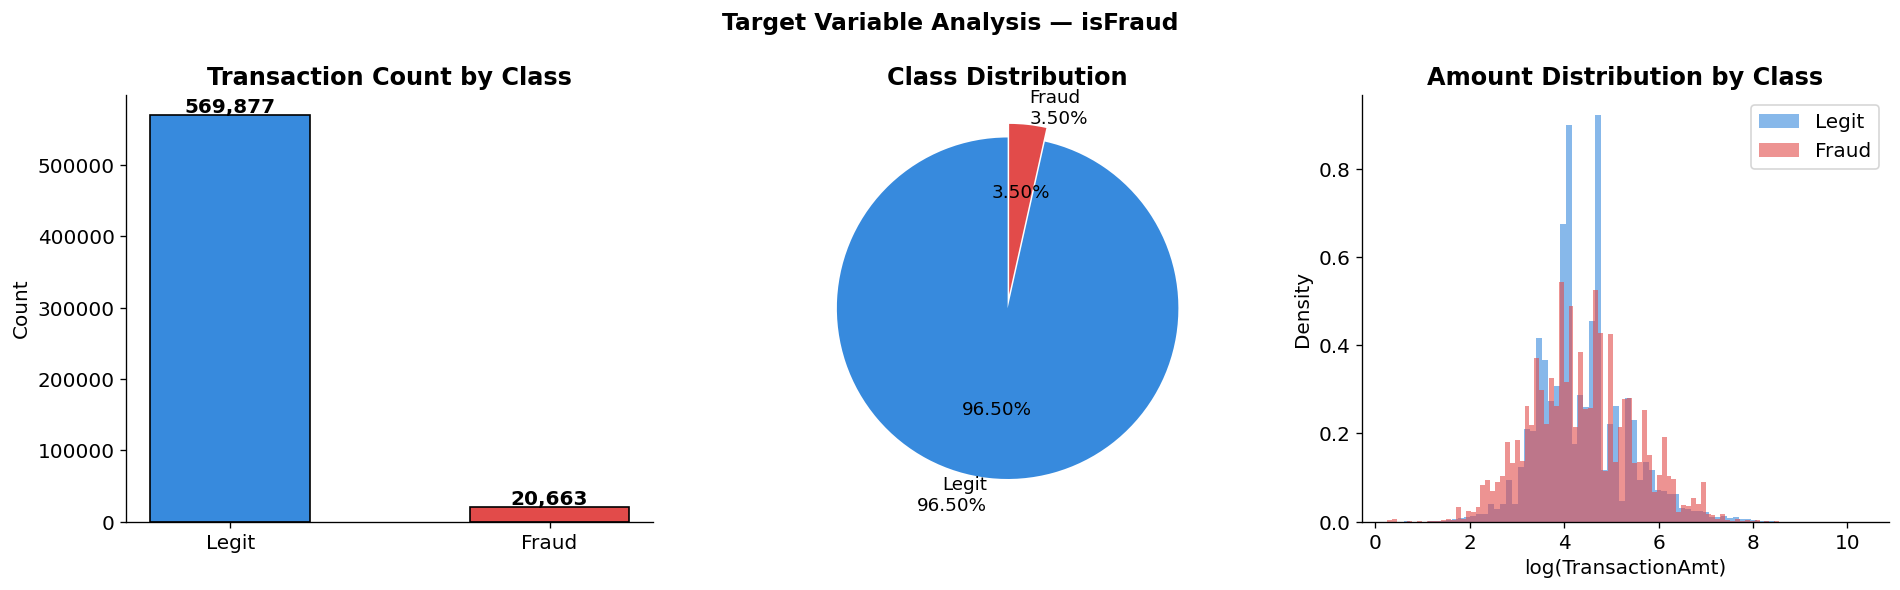

Saved: 01_target/target_analysis.png

Key insight:
  scale_pos_weight = 28  (XGBoost)
  is_unbalance = True             (LightGBM)
  auto_class_weights = 'Balanced' (CatBoost)


In [4]:
print('='*45)
print('TARGET VARIABLE — isFraud')
print('='*45)
print(f'  Legit (0)       : {len(legit):>7,}  ({len(legit)/len(df)*100:.2f}%)')
print(f'  Fraud (1)       : {len(fraud):>7,}  ({len(fraud)/len(df)*100:.2f}%)')
print(f'  Imbalance ratio : {len(legit)/len(fraud):.1f} : 1')
print(f'  scale_pos_weight: {len(legit)/len(fraud):.0f}  (for XGBoost)')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(
    ['Legit', 'Fraud'], [len(legit), len(fraud)],
    color=[PALETTE['legit'], PALETTE['fraud']], edgecolor='black', width=0.5
)
axes[0].set_title('Transaction Count by Class', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([len(legit), len(fraud)]):
    axes[0].text(i, v + 3000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(
    [len(legit), len(fraud)],
    labels=['Legit\n96.50%', 'Fraud\n3.50%'],
    colors=[PALETTE['legit'], PALETTE['fraud']],
    autopct='%1.2f%%', startangle=90,
    explode=(0, 0.08), textprops={'fontsize': 11}
)
axes[1].set_title('Class Distribution', fontweight='bold')

axes[2].hist(np.log1p(legit['TransactionAmt']), bins=80, alpha=0.6,
             color=PALETTE['legit'], label='Legit', density=True)
axes[2].hist(np.log1p(fraud['TransactionAmt']), bins=80, alpha=0.6,
             color=PALETTE['fraud'], label='Fraud', density=True)
axes[2].set_xlabel('log(TransactionAmt)')
axes[2].set_ylabel('Density')
axes[2].set_title('Amount Distribution by Class', fontweight='bold')
axes[2].legend()

plt.suptitle('Target Variable Analysis — isFraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_target' / 'target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: 01_target/target_analysis.png')
print(f'\nKey insight:')
print(f'  scale_pos_weight = {len(legit)/len(fraud):.0f}  (XGBoost)')
print(f'  is_unbalance = True             (LightGBM)')
print(f"  auto_class_weights = 'Balanced' (CatBoost)")

---
## 4. Transaction Amount Analysis

TransactionAmt has extreme right skewness (14.37). Log transformation reduces this to 0.49, enabling gradient boosting models to learn amount patterns more effectively.

**Decision:** `FE_amt_log = log1p(TransactionAmt)` added as engineered feature.

> **Saved:** `outputs/figures/fraud/eda/03_amount/amount_analysis.png`

TRANSACTION AMOUNT — STATISTICS
count    590540.00
mean        135.03
std         239.16
min           0.25
25%          43.32
50%          68.77
75%         125.00
max       31937.39
Name: TransactionAmt, dtype: float64

  Skewness (raw)    : 14.37
  Skewness (log1p)  : 0.49
  Kurtosis          : 1123.96

Fraud vs Legit — amount statistics:
           mean  median       max
isFraud                          
0        134.51    68.5  31937.39
1        149.24    75.0   5191.00


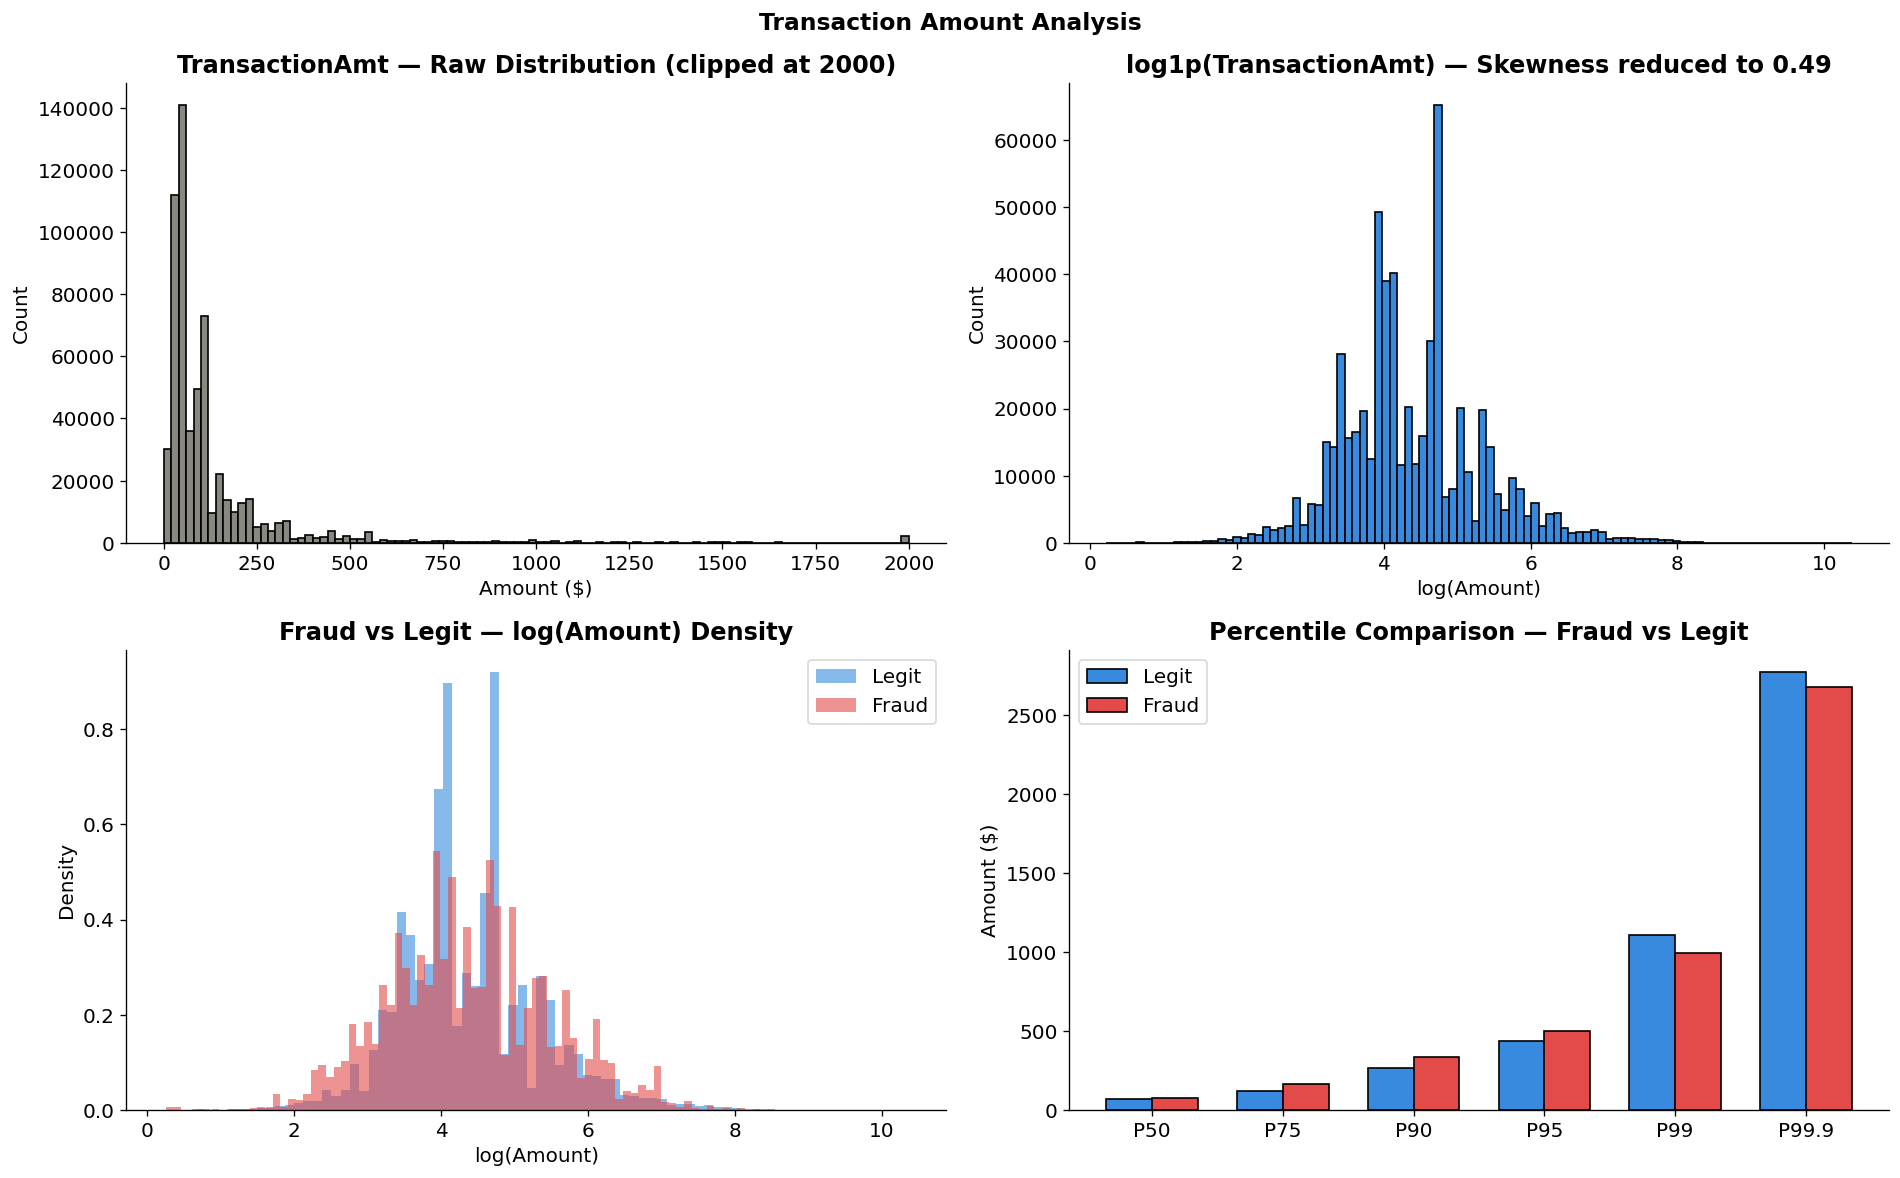


Decision:
  Raw skewness : 14.37  — too high for tree models
  Log skewness : 0.49  — acceptable
  FE_amt_log = log1p(TransactionAmt) added to pipeline
Saved: 03_amount/amount_analysis.png


In [5]:
print('='*50)
print('TRANSACTION AMOUNT — STATISTICS')
print('='*50)
print(df['TransactionAmt'].describe().round(2))
print(f'\n  Skewness (raw)    : {df["TransactionAmt"].skew():.2f}')
print(f'  Skewness (log1p)  : {np.log1p(df["TransactionAmt"]).skew():.2f}')
print(f'  Kurtosis          : {df["TransactionAmt"].kurt():.2f}')

print(f'\nFraud vs Legit — amount statistics:')
print(df.groupby('isFraud')['TransactionAmt'].agg(['mean','median','max']).round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].hist(df['TransactionAmt'].clip(upper=2000), bins=100,
               color=PALETTE['neutral'], edgecolor='black')
axes[0,0].set_title('TransactionAmt — Raw Distribution (clipped at 2000)', fontweight='bold')
axes[0,0].set_xlabel('Amount ($)')
axes[0,0].set_ylabel('Count')

axes[0,1].hist(np.log1p(df['TransactionAmt']), bins=100,
               color=PALETTE['legit'], edgecolor='black')
axes[0,1].set_title('log1p(TransactionAmt) — Skewness reduced to 0.49', fontweight='bold')
axes[0,1].set_xlabel('log(Amount)')
axes[0,1].set_ylabel('Count')

axes[1,0].hist(np.log1p(legit['TransactionAmt']), bins=80, alpha=0.6,
               color=PALETTE['legit'], label='Legit', density=True)
axes[1,0].hist(np.log1p(fraud['TransactionAmt']), bins=80, alpha=0.6,
               color=PALETTE['fraud'], label='Fraud', density=True)
axes[1,0].set_title('Fraud vs Legit — log(Amount) Density', fontweight='bold')
axes[1,0].set_xlabel('log(Amount)')
axes[1,0].set_ylabel('Density')
axes[1,0].legend()

pcts = [50, 75, 90, 95, 99, 99.9]
fraud_pcts = np.percentile(fraud['TransactionAmt'], pcts)
legit_pcts = np.percentile(legit['TransactionAmt'], pcts)
x = np.arange(len(pcts))
w = 0.35
axes[1,1].bar(x - w/2, legit_pcts, w, color=PALETTE['legit'], label='Legit', edgecolor='black')
axes[1,1].bar(x + w/2, fraud_pcts, w, color=PALETTE['fraud'], label='Fraud', edgecolor='black')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels([f'P{p}' for p in pcts])
axes[1,1].set_title('Percentile Comparison — Fraud vs Legit', fontweight='bold')
axes[1,1].set_ylabel('Amount ($)')
axes[1,1].legend()

plt.suptitle('Transaction Amount Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_amount' / 'amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

raw_skew = df['TransactionAmt'].skew()
log_skew = np.log1p(df['TransactionAmt']).skew()
print(f'\nDecision:')
print(f'  Raw skewness : {raw_skew:.2f}  — too high for tree models')
print(f'  Log skewness : {log_skew:.2f}  — acceptable')
print(f'  FE_amt_log = log1p(TransactionAmt) added to pipeline')
print('Saved: 03_amount/amount_analysis.png')

---
## 5. Temporal Analysis

TransactionDT is seconds since a reference point. Using `START_DATE = 2017-12-01` (consistent across all pipeline modules), we extract hour, day of week, and month features.

**Key finding:** Fraud rate peaks at hours 5–9 (low volume, high fraud concentration). This defines `PEAK_FRAUD_HOURS = [5, 6, 7, 8, 9]`.

> **Saved:** `outputs/figures/fraud/eda/04_temporal/temporal_analysis.png`

TEMPORAL COVERAGE
  Start : 2017-12-02 00:00:00
  End   : 2018-06-01 23:58:51
  Span  : 181 days


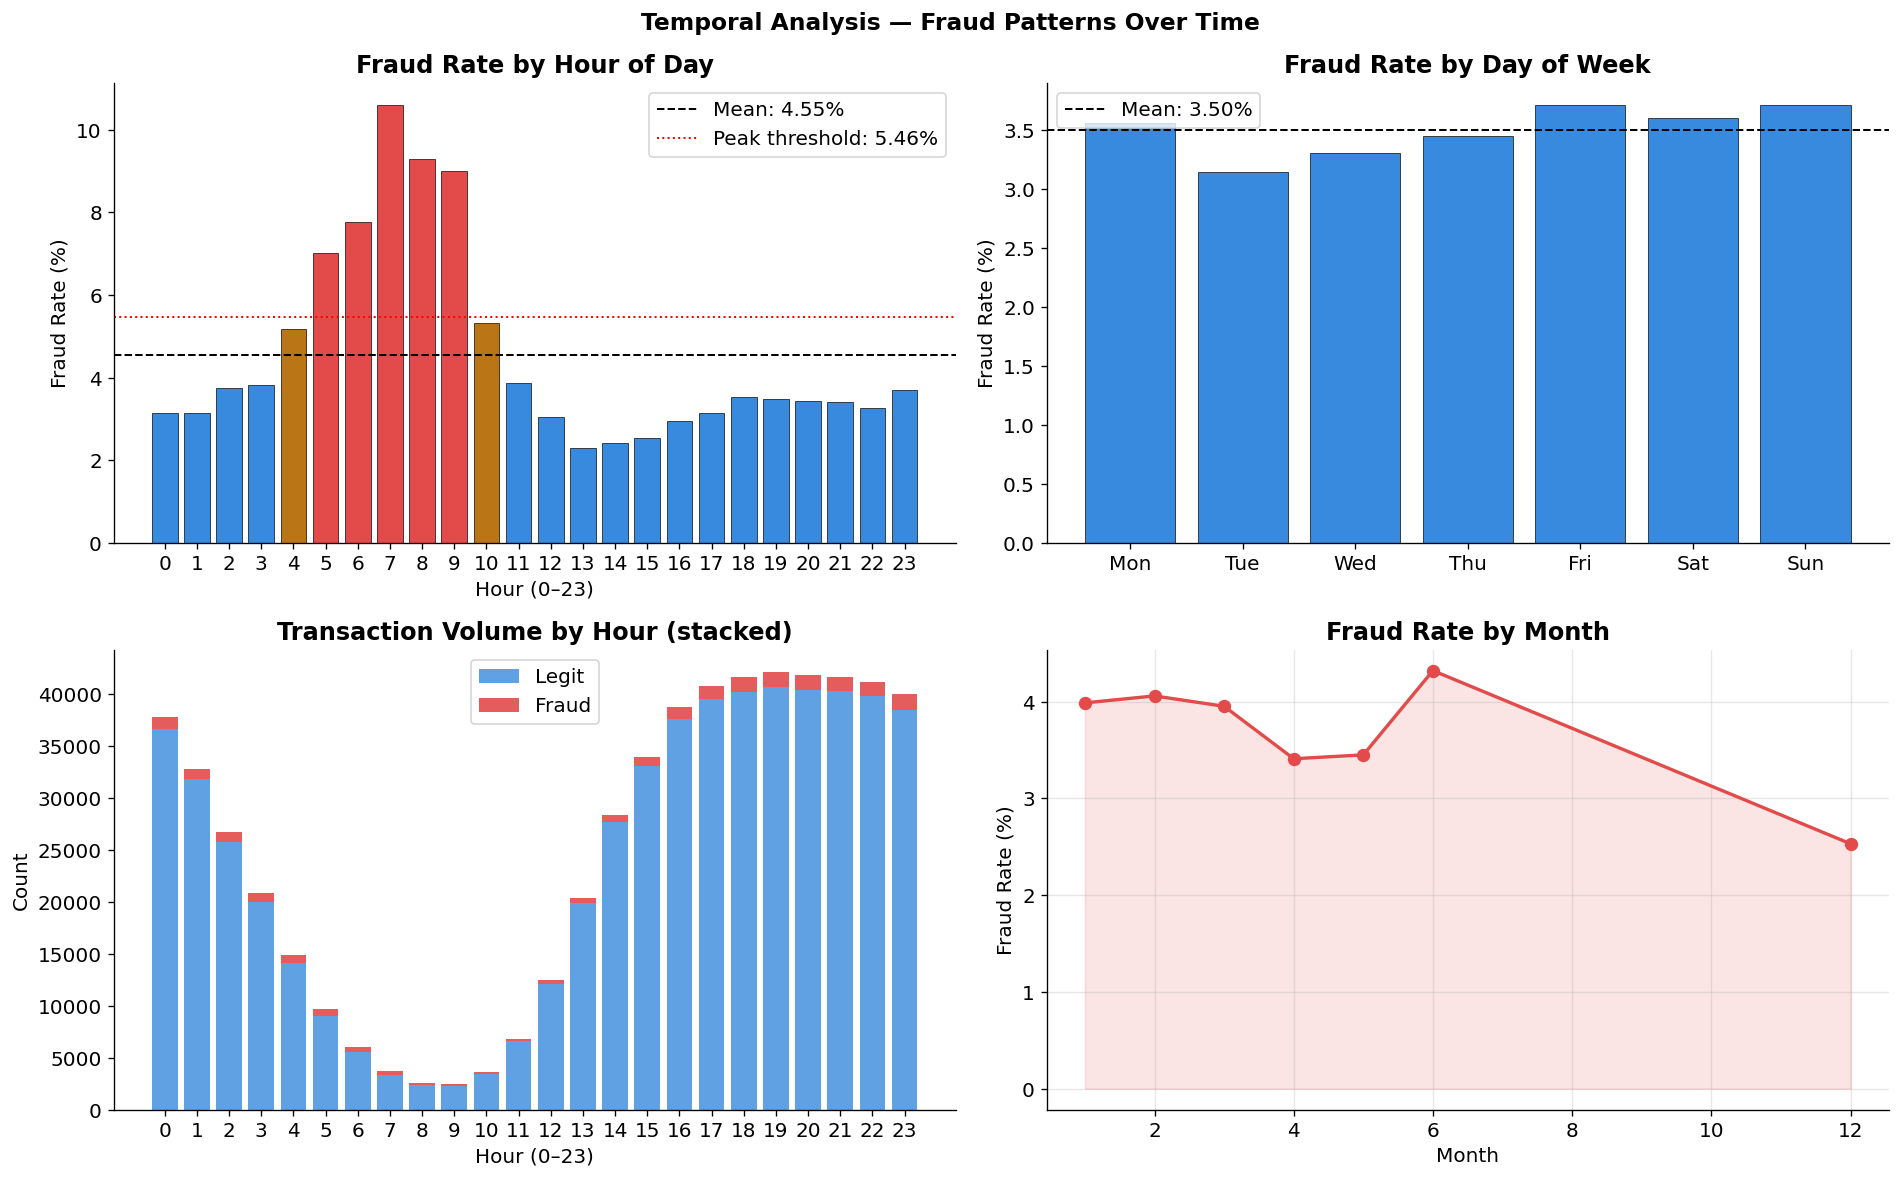

Saved: 04_temporal/temporal_analysis.png

Hourly fraud rate table:
       fraud_rate  total
_hour                   
0            3.14  37795
1            3.13  32797
2            3.75  26732
3            3.83  20802
4            5.19  14839
5            7.03   9701
6            7.77   6007
7           10.61   3704
8            9.30   2591
9            9.00   2479
10           5.32   3627
11           3.88   6827
12           3.04  12451
13           2.29  20315
14           2.42  28328
15           2.54  33859
16           2.95  38698
17           3.15  40723
18           3.52  41639
19           3.47  42115
20           3.43  41782
21           3.40  41641
22           3.27  41139
23           3.70  39949

Peak fraud hours (rate > 5.46%): [5, 6, 7, 8, 9]
Decision: PEAK_FRAUD_HOURS = [5, 6, 7, 8, 9]


In [6]:
START_DATE = pd.Timestamp('2017-12-01')

dt           = START_DATE + pd.to_timedelta(df['TransactionDT'], unit='s')
df['_hour']  = dt.dt.hour
df['_dow']   = dt.dt.dayofweek
df['_month'] = dt.dt.month

print('='*50)
print('TEMPORAL COVERAGE')
print('='*50)
print(f'  Start : {dt.min()}')
print(f'  End   : {dt.max()}')
print(f'  Span  : {(dt.max() - dt.min()).days} days')

hourly = df.groupby('_hour')['isFraud'].agg(fraud_count='sum', total='count')
hourly['fraud_rate'] = hourly['fraud_count'] / hourly['total'] * 100

dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily = df.groupby('_dow')['isFraud'].agg(fraud_count='sum', total='count')
daily['fraud_rate'] = daily['fraud_count'] / daily['total'] * 100

monthly = df.groupby('_month')['isFraud'].agg(fraud_count='sum', total='count')
monthly['fraud_rate'] = monthly['fraud_count'] / monthly['total'] * 100

mean_fraud_rate = hourly['fraud_rate'].mean()
threshold_peak  = mean_fraud_rate * 1.2
peak_hours      = hourly[hourly['fraud_rate'] > threshold_peak].index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colors_hour = [
    PALETTE['fraud']     if r > mean_fraud_rate * 1.2
    else PALETTE['highlight'] if r > mean_fraud_rate
    else PALETTE['legit']
    for r in hourly['fraud_rate']
]
axes[0,0].bar(hourly.index, hourly['fraud_rate'], color=colors_hour, edgecolor='black', linewidth=0.4)
axes[0,0].axhline(mean_fraud_rate, color='black', ls='--', lw=1.2, label=f'Mean: {mean_fraud_rate:.2f}%')
axes[0,0].axhline(threshold_peak,  color='red',   ls=':', lw=1.2,  label=f'Peak threshold: {threshold_peak:.2f}%')
axes[0,0].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[0,0].set_xlabel('Hour (0–23)')
axes[0,0].set_ylabel('Fraud Rate (%)')
axes[0,0].set_xticks(range(0, 24))
axes[0,0].legend()

axes[0,1].bar(range(7), daily['fraud_rate'], color=PALETTE['legit'], edgecolor='black', linewidth=0.4)
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels(dow_labels)
axes[0,1].axhline(daily['fraud_rate'].mean(), color='black', ls='--', lw=1.2,
                  label=f"Mean: {daily['fraud_rate'].mean():.2f}%")
axes[0,1].set_title('Fraud Rate by Day of Week', fontweight='bold')
axes[0,1].set_ylabel('Fraud Rate (%)')
axes[0,1].legend()

axes[1,0].bar(hourly.index, hourly['total'] - hourly['fraud_count'],
              color=PALETTE['legit'], label='Legit', alpha=0.8)
axes[1,0].bar(hourly.index, hourly['fraud_count'],
              bottom=hourly['total'] - hourly['fraud_count'],
              color=PALETTE['fraud'], label='Fraud', alpha=0.9)
axes[1,0].set_title('Transaction Volume by Hour (stacked)', fontweight='bold')
axes[1,0].set_xlabel('Hour (0–23)')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xticks(range(0, 24))
axes[1,0].legend()

axes[1,1].plot(monthly.index, monthly['fraud_rate'],
               marker='o', color=PALETTE['fraud'], lw=2, markersize=7)
axes[1,1].fill_between(monthly.index, monthly['fraud_rate'], alpha=0.15, color=PALETTE['fraud'])
axes[1,1].set_title('Fraud Rate by Month', fontweight='bold')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Fraud Rate (%)')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Temporal Analysis — Fraud Patterns Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_temporal' / 'temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: 04_temporal/temporal_analysis.png')
print(f'\nHourly fraud rate table:')
print(hourly[['fraud_rate','total']].round(2).to_string())
print(f'\nPeak fraud hours (rate > {threshold_peak:.2f}%): {peak_hours}')
print(f'Decision: PEAK_FRAUD_HOURS = [5, 6, 7, 8, 9]')

---
## 6. Card Features Analysis

Card features provide key behavioral signals:
- `card6 = 'credit'` → 6.68% fraud vs 2.43% debit (2.75× higher)
- `card4 = 'discover'` → highest fraud rate by network
- `card1 + addr1` combination → 39.5% singleton combos → frequency encoding justified

> **Saved:** `outputs/figures/fraud/eda/05_card/card_features.png`

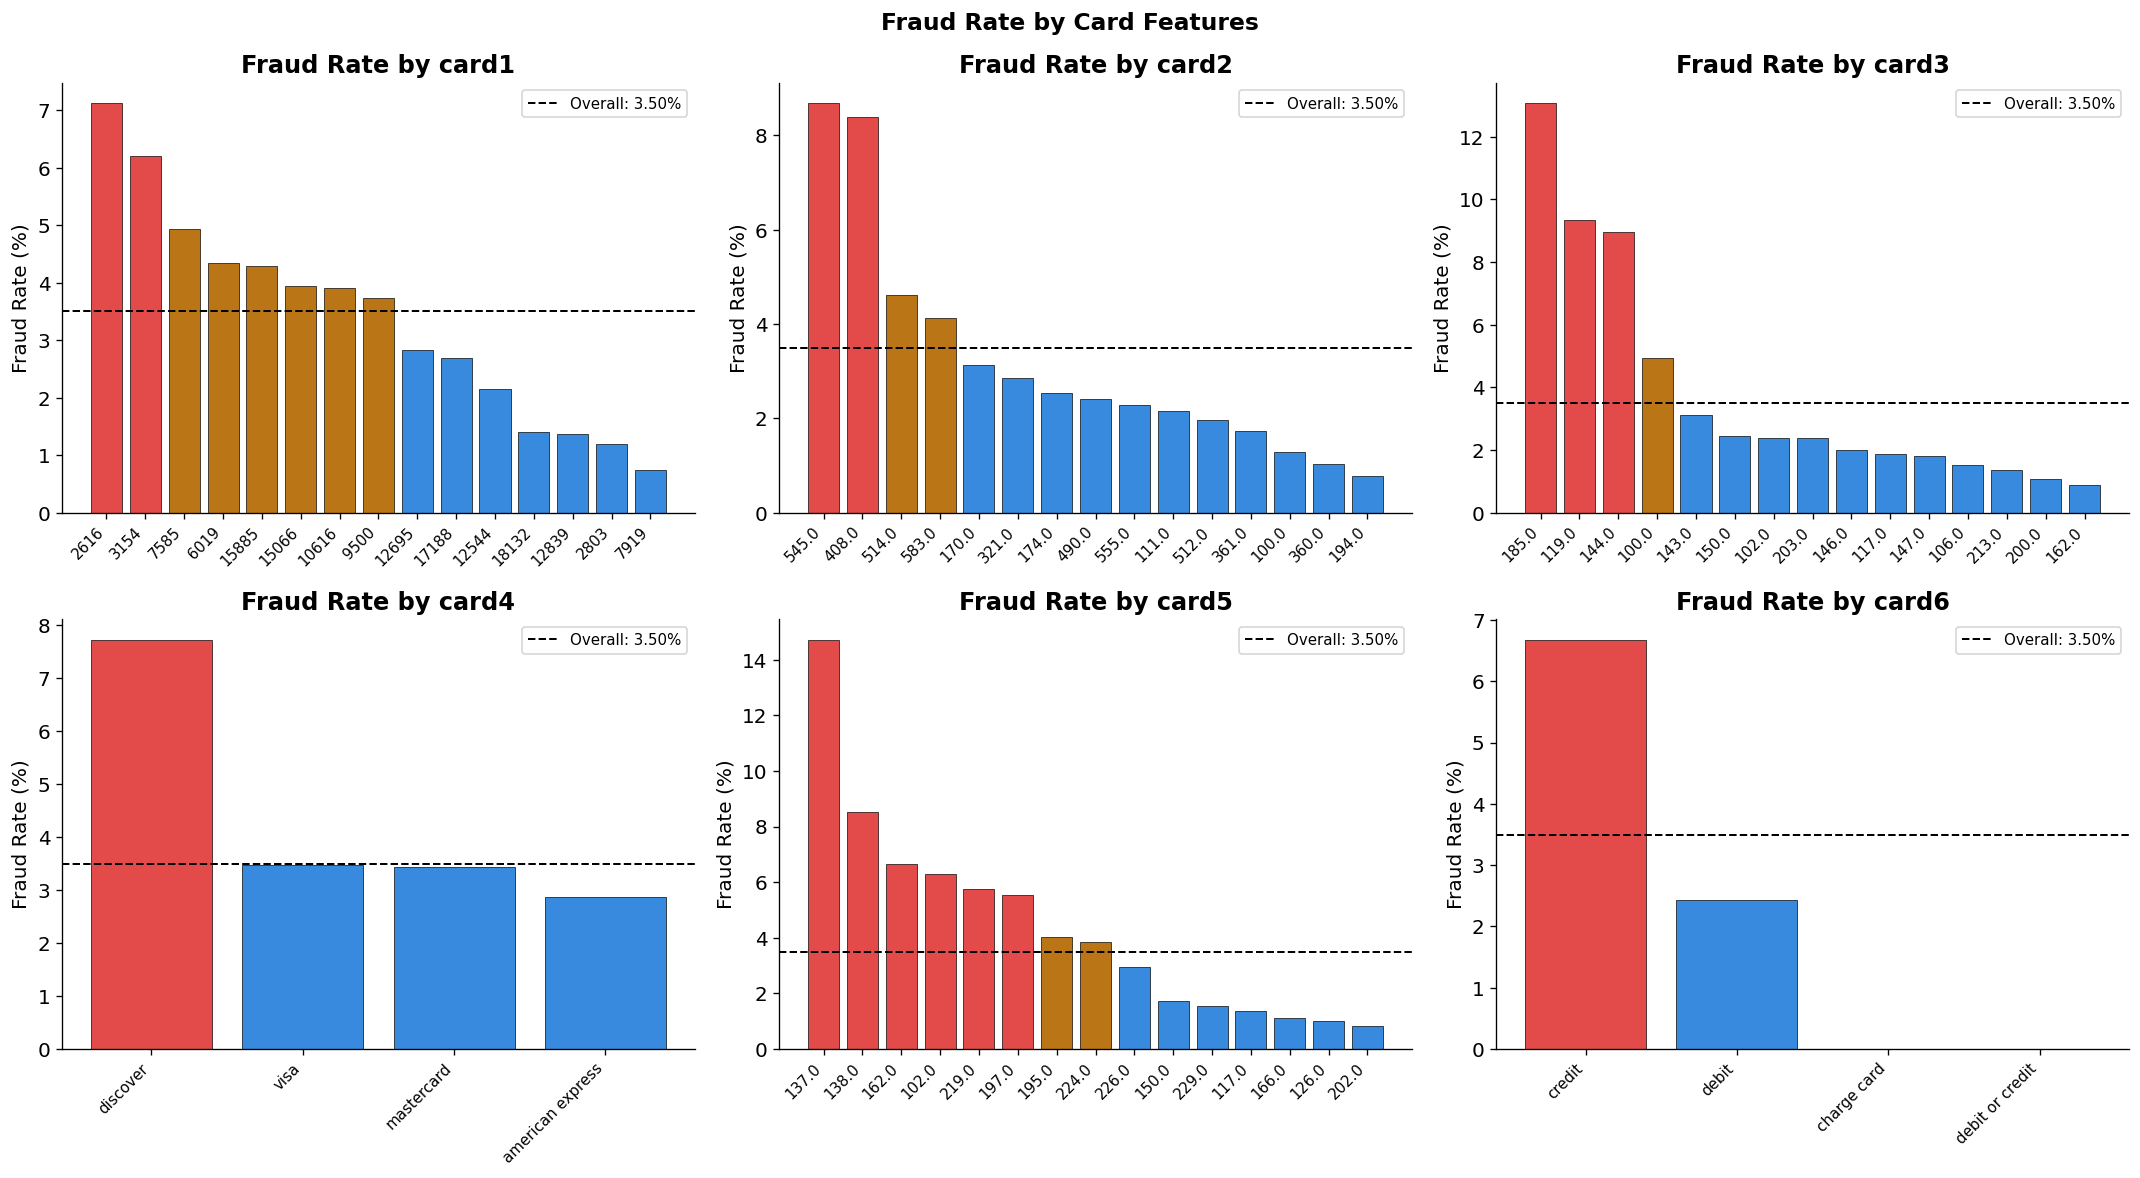

CARD4 — Card Network Fraud Rate
                  fraud_rate   count
card4                               
discover               7.728    6651
visa                   3.476  384767
mastercard             3.433  189217
american express       2.870    8328
NaN                    2.600    1577

CARD6 — Card Type Fraud Rate
                 fraud_rate   count
card6                              
credit                6.678  148986
NaN                   2.482    1571
debit                 2.426  439938
charge card           0.000      15
debit or credit       0.000      30

CARD1 + ADDR1 COMBINATION
  Unique combos   : 458
  Singletons (n=1): 14,818 (39.5%)
  Decision: card1_addr1 frequency encoding is justified
Saved: 05_card/card_features.png


In [7]:
card_cols          = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']
overall_fraud_rate = df['isFraud'].mean() * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(card_cols):
    tmp   = df[[col, 'isFraud']].dropna(subset=[col]).copy()
    tmp[col] = tmp[col].astype(str)
    stats = (
        tmp.groupby(col)['isFraud']
        .agg(fraud_rate='mean', count='count')
        .reset_index()
    )
    stats['fraud_rate'] = stats['fraud_rate'] * 100

    if tmp[col].nunique() > 15:
        top_vals = stats.nlargest(15, 'count').sort_values('fraud_rate', ascending=False).reset_index(drop=True)
    else:
        top_vals = stats.sort_values('fraud_rate', ascending=False).reset_index(drop=True)

    colors = [
        PALETTE['fraud']     if r > overall_fraud_rate * 1.5
        else PALETTE['highlight'] if r > overall_fraud_rate
        else PALETTE['legit']
        for r in top_vals['fraud_rate']
    ]
    bars = axes[idx].bar(range(len(top_vals)), top_vals['fraud_rate'],
                         color=colors, edgecolor='black', linewidth=0.4)
    axes[idx].set_xticks(range(len(top_vals)))
    axes[idx].set_xticklabels(top_vals[col].tolist(), rotation=45, ha='right', fontsize=9)
    axes[idx].axhline(overall_fraud_rate, color='black', ls='--', lw=1.2,
                      label=f'Overall: {overall_fraud_rate:.2f}%')
    axes[idx].set_title(f'Fraud Rate by {col}', fontweight='bold')
    axes[idx].set_ylabel('Fraud Rate (%)')
    axes[idx].legend(fontsize=9)

plt.suptitle('Fraud Rate by Card Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_card' / 'card_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('='*50)
print('CARD4 — Card Network Fraud Rate')
print('='*50)
print(df.groupby('card4', dropna=False)['isFraud']
      .agg(fraud_rate='mean', count='count')
      .assign(fraud_rate=lambda x: (x['fraud_rate'] * 100).round(3))
      .sort_values('fraud_rate', ascending=False).to_string())

print('\n' + '='*50)
print('CARD6 — Card Type Fraud Rate')
print('='*50)
print(df.groupby('card6', dropna=False)['isFraud']
      .agg(fraud_rate='mean', count='count')
      .assign(fraud_rate=lambda x: (x['fraud_rate'] * 100).round(3))
      .sort_values('fraud_rate', ascending=False).to_string())

combo        = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
combo_counts = combo.value_counts()
print('\n' + '='*50)
print('CARD1 + ADDR1 COMBINATION')
print('='*50)
print(f'  Unique combos   : {combo_counts.nunique():,}')
print(f'  Singletons (n=1): {(combo_counts==1).sum():,} ({(combo_counts==1).sum()/len(combo_counts)*100:.1f}%)')
print('  Decision: card1_addr1 frequency encoding is justified')
print('Saved: 05_card/card_features.png')

---
## 7. Email Domain Risk Analysis

Email domains show strong fraud signal:
- `protonmail.com` → ~40% fraud rate (privacy-focused, used by fraudsters)
- Several domains show fraud rate >2× overall average → `HIGH_RISK_EMAIL_DOMAINS` list
- Proton domains kept separate — extreme rate despite low count

> **Saved:** `outputs/figures/fraud/eda/06_email/email_domain_analysis.png`

EMAIL DOMAIN — OVERVIEW
  P_emaildomain missing : 16.0%
  R_emaildomain missing : 76.8%
  P_emaildomain unique  : 59
  R_emaildomain unique  : 60

P_emaildomain — all domains (sorted by fraud rate):
   P_emaildomain  fraud_rate  count
  protonmail.com   40.789474     76
        mail.com   18.962433    559
      outlook.es   13.013699    438
         aim.com   12.698413    315
     outlook.com    9.458399   5096
      hotmail.es    6.557377    305
     live.com.mx    5.473965    749
     hotmail.com    5.295028  45250
       gmail.com    4.354185 228355
        yahoo.fr    3.496503    143
  embarqmail.com    3.461538    260
         mac.com    3.211009    436
      icloud.com    3.143450   6267
     comcast.net    3.118661   7888
     charter.net    3.063725    816
             NaN    2.953756  94456
    frontier.com    2.857143    280
   bellsouth.net    2.776323   1909
        live.com    2.762249   3041
 frontiernet.net    2.564103    195
   anonymous.com    2.321747  36998
  suddenl

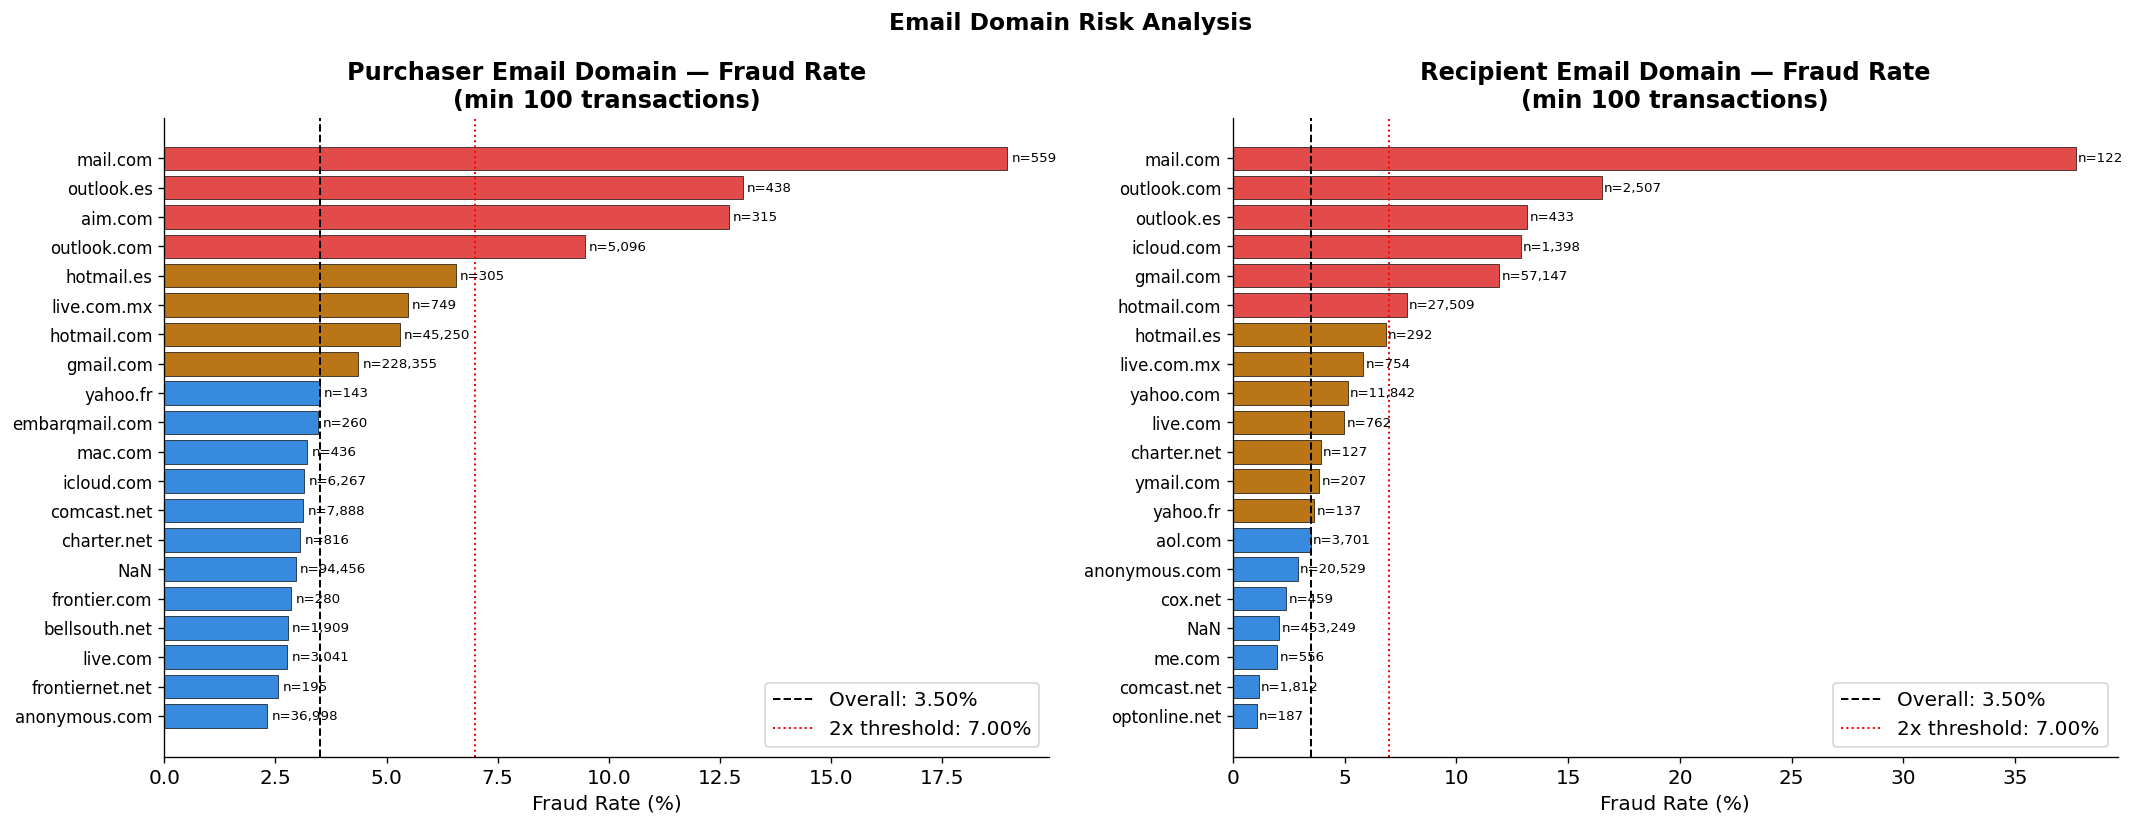


High-risk email domains (fraud rate > 7.0%, min 100 transactions):
P_emaildomain  fraud_rate  count
     mail.com   18.962433    559
   outlook.es   13.013699    438
      aim.com   12.698413    315
  outlook.com    9.458399   5096
Saved: 06_email/email_domain_analysis.png


In [8]:
overall_fraud_rate = df['isFraud'].mean() * 100

print('='*50)
print('EMAIL DOMAIN — OVERVIEW')
print('='*50)
print(f'  P_emaildomain missing : {df["P_emaildomain"].isnull().mean()*100:.1f}%')
print(f'  R_emaildomain missing : {df["R_emaildomain"].isnull().mean()*100:.1f}%')
print(f'  P_emaildomain unique  : {df["P_emaildomain"].nunique()}')
print(f'  R_emaildomain unique  : {df["R_emaildomain"].nunique()}')

p_stats = (
    df.groupby('P_emaildomain', dropna=False)['isFraud']
    .agg(fraud_rate='mean', count='count').reset_index()
)
p_stats['fraud_rate'] = p_stats['fraud_rate'] * 100
p_stats = p_stats.sort_values('fraud_rate', ascending=False)

r_stats = (
    df.groupby('R_emaildomain', dropna=False)['isFraud']
    .agg(fraud_rate='mean', count='count').reset_index()
)
r_stats['fraud_rate'] = r_stats['fraud_rate'] * 100
r_stats = r_stats.sort_values('fraud_rate', ascending=False)

print('\nP_emaildomain — all domains (sorted by fraud rate):')
print(p_stats.to_string(index=False))
print('\nR_emaildomain — all domains (sorted by fraud rate):')
print(r_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, stats, col, title in [
    (axes[0], p_stats, 'P_emaildomain', 'Purchaser Email Domain'),
    (axes[1], r_stats, 'R_emaildomain', 'Recipient Email Domain'),
]:
    plot = stats[stats['count'] >= 100].head(20).reset_index(drop=True)
    colors = [
        PALETTE['fraud']     if r > overall_fraud_rate * 2
        else PALETTE['highlight'] if r > overall_fraud_rate
        else PALETTE['legit']
        for r in plot['fraud_rate']
    ]
    bars = ax.barh(range(len(plot)), plot['fraud_rate'],
                   color=colors, edgecolor='black', linewidth=0.4)
    ax.set_yticks(range(len(plot)))
    ax.set_yticklabels(plot[col].fillna('NaN').tolist(), fontsize=10)
    ax.axvline(overall_fraud_rate, color='black', ls='--', lw=1.2,
               label=f'Overall: {overall_fraud_rate:.2f}%')
    ax.axvline(overall_fraud_rate * 2, color='red', ls=':', lw=1.2,
               label=f'2x threshold: {overall_fraud_rate*2:.2f}%')
    ax.invert_yaxis()
    ax.set_xlabel('Fraud Rate (%)')
    ax.set_title(f'{title} — Fraud Rate\n(min 100 transactions)', fontweight='bold')
    ax.legend()
    for bar, cnt in zip(bars, plot['count']):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'n={cnt:,}', va='center', fontsize=8)

plt.suptitle('Email Domain Risk Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_email' / 'email_domain_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

high_risk = p_stats[(p_stats['fraud_rate'] > overall_fraud_rate * 2) & (p_stats['count'] >= 100)]
print(f'\nHigh-risk email domains (fraud rate > {overall_fraud_rate*2:.1f}%, min 100 transactions):')
print(high_risk[['P_emaildomain','fraud_rate','count']].to_string(index=False))
print('Saved: 06_email/email_domain_analysis.png')

---
## 8. Browser & Device Analysis

Browser and device type show meaningful fraud rate differences:
- Mobile devices → higher fraud rate than desktop
- Certain browser families (Opera, Android browser) → elevated fraud

**Decisions:**
- `RISKY_BROWSERS = ['opera', 'android', 'samsung', 'firefox', 'mobile']`
- `FE_browser_is_risky` and `FE_device_is_mobile` added as binary features

> **Saved:** `outputs/figures/fraud/eda/07_browser_device/browser_device_analysis.png`

BROWSER & DEVICE — OVERVIEW
  id_31 (browser) missing  : 76.2%
  DeviceType missing       : 76.2%
  id_31 unique values      : 130
  DeviceType unique values : 2

Browser family fraud rates:
         _browser  fraud_rate  count
  mozilla/firefox  100.000000      5
        icedragon  100.000000      5
           comodo   66.666667      6
      lanix/ilium   66.666667      3
            opera   31.625835    449
        zte/blade   22.222222      9
          android   21.761658    386
            other   19.551282    312
  generic/android   16.666667    138
 samsung/sm-g532m   11.333333    150
           chrome    9.595183  76059
          samsung    8.708415   2044
          firefox    7.815174   7012
           mobile    7.551358  28379
             edge    3.515076   6401
           safari    2.737574   8913
          unknown    2.108125 450258
           google    2.054795    146
 samsung/sm-g531h    1.923077     52
               ie    1.911024   9733
           puffin    0.000000   

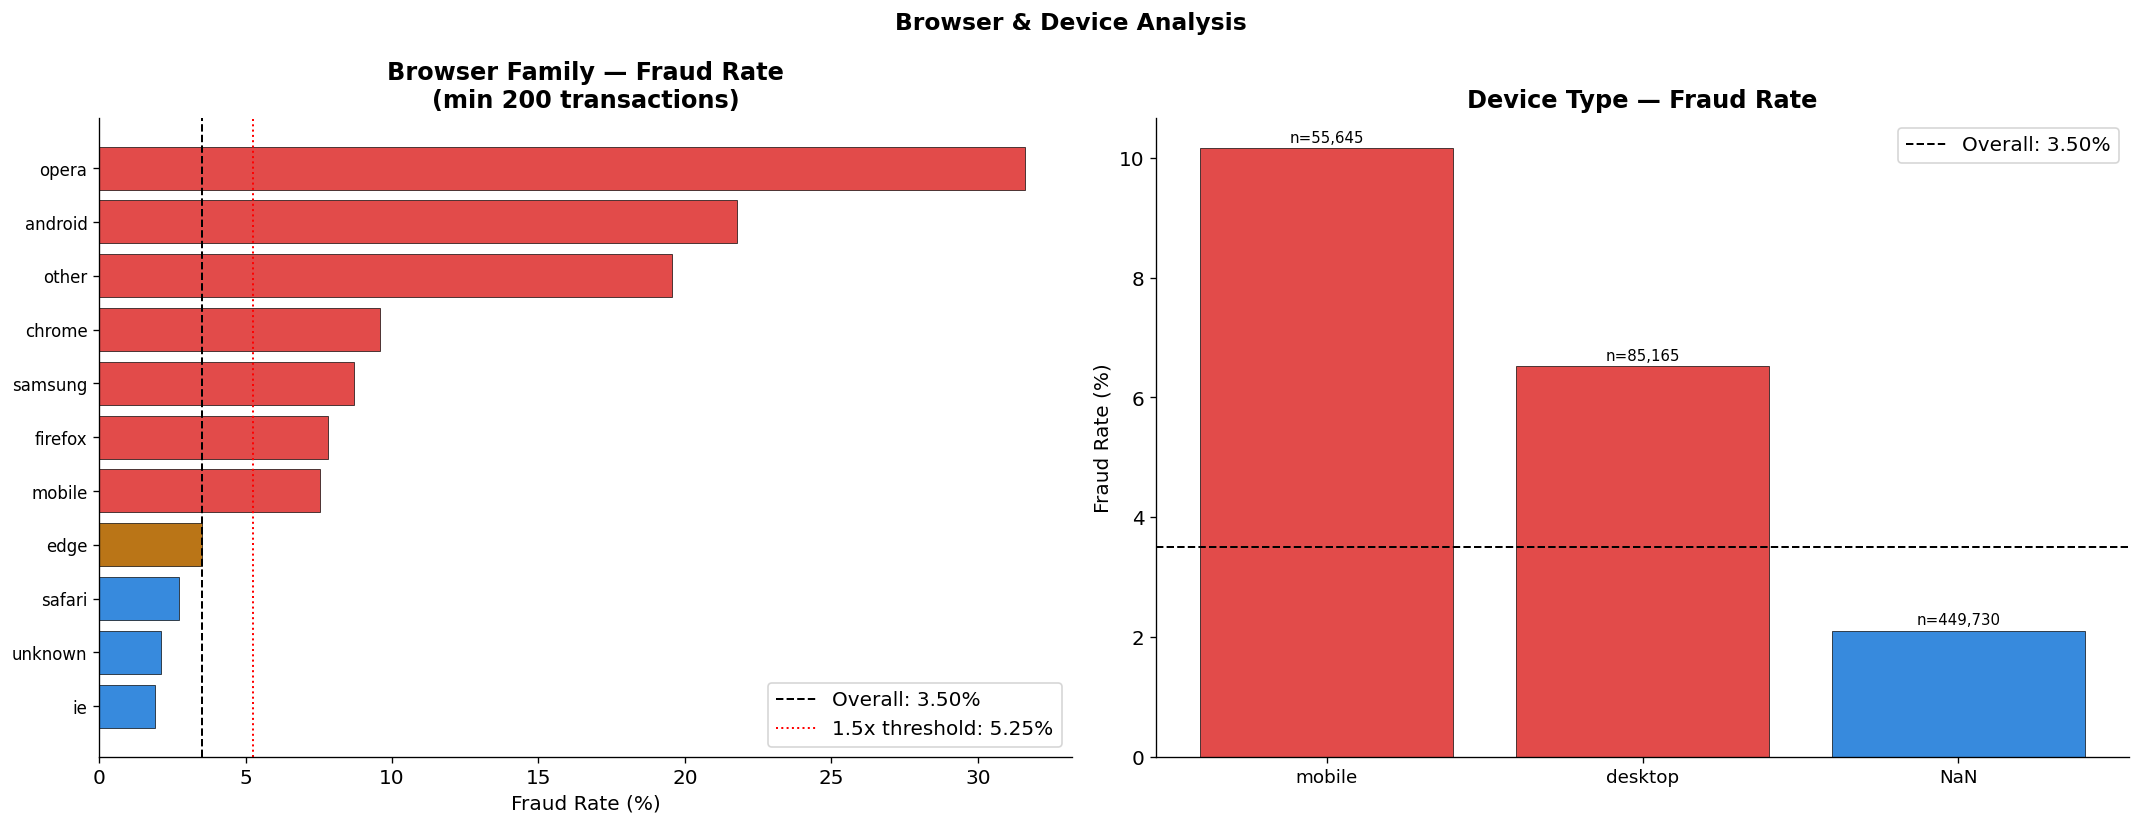

Saved: 07_browser_device/browser_device_analysis.png


In [9]:
overall_fraud_rate = df['isFraud'].mean() * 100

print('='*50)
print('BROWSER & DEVICE — OVERVIEW')
print('='*50)
print(f'  id_31 (browser) missing  : {df["id_31"].isnull().mean()*100:.1f}%')
print(f'  DeviceType missing       : {df["DeviceType"].isnull().mean()*100:.1f}%')
print(f'  id_31 unique values      : {df["id_31"].nunique()}')
print(f'  DeviceType unique values : {df["DeviceType"].nunique()}')

df['_browser'] = df['id_31'].str.lower().str.split().str[0].fillna('unknown')

browser_stats = (
    df.groupby('_browser')['isFraud']
    .agg(fraud_rate='mean', count='count').reset_index()
)
browser_stats['fraud_rate'] = browser_stats['fraud_rate'] * 100
browser_stats = browser_stats.sort_values('fraud_rate', ascending=False)

device_stats = (
    df.groupby('DeviceType', dropna=False)['isFraud']
    .agg(fraud_rate='mean', count='count').reset_index()
)
device_stats['fraud_rate'] = device_stats['fraud_rate'] * 100
device_stats = device_stats.sort_values('fraud_rate', ascending=False)

print('\nBrowser family fraud rates:')
print(browser_stats.to_string(index=False))
print('\nDevice type fraud rates:')
print(device_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

b_plot = browser_stats[browser_stats['count'] >= 200].reset_index(drop=True)
colors_b = [
    PALETTE['fraud']     if r > overall_fraud_rate * 1.5
    else PALETTE['highlight'] if r > overall_fraud_rate
    else PALETTE['legit']
    for r in b_plot['fraud_rate']
]
bars_b = axes[0].barh(range(len(b_plot)), b_plot['fraud_rate'],
                      color=colors_b, edgecolor='black', linewidth=0.4)
axes[0].set_yticks(range(len(b_plot)))
axes[0].set_yticklabels(b_plot['_browser'].tolist(), fontsize=10)
axes[0].axvline(overall_fraud_rate, color='black', ls='--', lw=1.2,
                label=f'Overall: {overall_fraud_rate:.2f}%')
axes[0].axvline(overall_fraud_rate * 1.5, color='red', ls=':', lw=1.2,
                label=f'1.5x threshold: {overall_fraud_rate*1.5:.2f}%')
axes[0].invert_yaxis()
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_title('Browser Family — Fraud Rate\n(min 200 transactions)', fontweight='bold')
axes[0].legend()

d_plot    = device_stats.reset_index(drop=True)
colors_d  = [
    PALETTE['fraud']     if r > overall_fraud_rate * 1.5
    else PALETTE['highlight'] if r > overall_fraud_rate
    else PALETTE['legit']
    for r in d_plot['fraud_rate']
]
axes[1].bar(range(len(d_plot)), d_plot['fraud_rate'],
            color=colors_d, edgecolor='black', linewidth=0.4)
axes[1].set_xticks(range(len(d_plot)))
axes[1].set_xticklabels(d_plot['DeviceType'].fillna('NaN').tolist(), fontsize=11)
axes[1].axhline(overall_fraud_rate, color='black', ls='--', lw=1.2,
                label=f'Overall: {overall_fraud_rate:.2f}%')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Device Type — Fraud Rate', fontweight='bold')
axes[1].legend()
for i, (rate, cnt) in enumerate(zip(d_plot['fraud_rate'], d_plot['count'])):
    axes[1].text(i, rate + 0.1, f'n={cnt:,}', ha='center', fontsize=9)

plt.suptitle('Browser & Device Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_browser_device' / 'browser_device_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_browser_device/browser_device_analysis.png')

---
## 9. C, D, M, V Column Analysis

- **C columns** — count-type features (transaction counts). High correlation with isFraud for C5, C13.
- **D columns** — time delta features. Many have >50% missing. NaN pattern is non-random → NaN flags added.
- **M columns** — binary match features (T/F/NaN). NaN itself has 5.28% fraud rate — informative.
- **V columns** — Vesta proprietary features. Top by |correlation|: V257, V246, V244.

> **Saved:** `outputs/figures/fraud/eda/08_c_d_v_m/cdvm_analysis.png`

In [10]:
overall_fraud_rate = df['isFraud'].mean() * 100

c_cols = [c for c in df.columns if c.startswith('C') and c[1:].isdigit()]
d_cols = [c for c in df.columns if c.startswith('D') and c[1:].isdigit()]
m_cols = [c for c in df.columns if c.startswith('M') and c[1:].isdigit()]
v_cols = [c for c in df.columns if c.startswith('V') and c[1:].isdigit()]

print(f'C columns: {len(c_cols)} | D columns: {len(d_cols)} | M columns: {len(m_cols)} | V columns: {len(v_cols)}')

c_corr    = df[c_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').sort_values(key=abs, ascending=False)
d_missing = df[d_cols].isnull().mean() * 100
v_corr    = df[v_cols + ['isFraud']].corr()['isFraud'].drop('isFraud')
v_corr_abs = v_corr.abs().sort_values(ascending=False)

print('\nC columns — correlation with isFraud:')
print(c_corr.round(4).to_string())

print('\nD columns — missing rate:')
d_summary = pd.DataFrame({'missing_pct': d_missing, 'corr_fraud': df[d_cols + ['isFraud']].corr()['isFraud'].drop('isFraud')})
print(d_summary.sort_values('missing_pct', ascending=False).round(4).to_string())

print('\nM columns — fraud rate by T/F/NaN:')
for col in m_cols:
    stats = df.groupby(col, dropna=False)['isFraud'].agg(fraud_rate='mean', count='count').reset_index()
    stats['fraud_rate'] = (stats['fraud_rate'] * 100).round(2)
    print(f'  {col}: {dict(zip(stats[col].astype(str), stats["fraud_rate"]))}')

print('\nV columns — top 20 by |correlation|:')
v_corr_abs_sorted = v_corr.abs().sort_values(ascending=False)
v_top20_idx = v_corr_abs_sorted.dropna().head(20).index
v_top20 = pd.DataFrame({
    'corr_fraud' : v_corr[v_top20_idx],
    'missing_pct': df[v_top20_idx].isnull().mean() * 100,
})
print(v_top20.round(4).to_string())

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

colors_c = [PALETTE['fraud'] if v > 0 else PALETTE['legit'] for v in c_corr.values]
axes[0,0].barh(c_corr.index[::-1], c_corr.values[::-1], color=colors_c[::-1], edgecolor='black', linewidth=0.4)
axes[0,0].axvline(0, color='black', lw=0.8)
axes[0,0].set_title('C Columns — Correlation with isFraud', fontweight='bold')
axes[0,0].set_xlabel('Pearson Correlation')

colors_d = [PALETTE['fraud'] if v > 50 else PALETTE['highlight'] if v > 20 else PALETTE['legit']
            for v in d_missing.sort_values(ascending=False).values]
axes[0,1].barh(d_missing.sort_values(ascending=False).index[::-1],
               d_missing.sort_values(ascending=False).values[::-1],
               color=colors_d[::-1], edgecolor='black', linewidth=0.4)
axes[0,1].axvline(5,  color='green', ls='--', lw=1.2, label='5% — NaN flag threshold')
axes[0,1].axvline(90, color='red',   ls='--', lw=1.2, label='90% — drop threshold')
axes[0,1].set_title('D Columns — Missing Rate (%)', fontweight='bold')
axes[0,1].set_xlabel('Missing (%)')
axes[0,1].legend()

m4_stats = df.groupby('M4', dropna=False)['isFraud'].mean() * 100
m4_labels = [str(x) if pd.notna(x) else 'NaN' for x in m4_stats.index]
axes[1,0].bar(m4_labels, m4_stats.values, color=PALETTE['fraud'], edgecolor='black')
color=PALETTE['fraud'], edgecolor='black')
axes[1,0].axhline(overall_fraud_rate, color='black', ls='--', lw=1.2, label=f'Overall: {overall_fraud_rate:.2f}%')
axes[1,0].set_title('M4 — Fraud Rate by Value (strongest M signal)', fontweight='bold')
axes[1,0].set_ylabel('Fraud Rate (%)')
axes[1,0].legend()

v_top = v_top20.sort_values('corr_fraud')
colors_v = [PALETTE['fraud'] if v > 0 else PALETTE['legit'] for v in v_top['corr_fraud'].values]
axes[1,1].barh(v_top.index, v_top['corr_fraud'].values, color=colors_v, edgecolor='black', linewidth=0.4)
axes[1,1].axvline(0, color='black', lw=0.8)
axes[1,1].set_title('V Columns — Top 20 |Correlation| with isFraud', fontweight='bold')
axes[1,1].set_xlabel('Pearson Correlation')

plt.suptitle('C, D, M, V Column Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_c_d_v_m' / 'cdvm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 08_c_d_v_m/cdvm_analysis.png')

SyntaxError: unmatched ')' (3766612670.py, line 59)

---
## 10. Identity Features Analysis

Identity features are only available for ~24% of transactions (left join with identity table).

**Key signals:**
- `id_15 = 'Found'` → 10.51% fraud
- `id_35 = 'F'` → 12.26% fraud
- `id_17` numeric → strongest numeric identity correlation

> **Saved:** `outputs/figures/fraud/eda/09_identity/identity_analysis.png`

In [ ]:
id_cols = [c for c in df.columns if c.startswith('id_')]
id_num  = [c for c in id_cols if pd.api.types.is_numeric_dtype(df[c])]
id_cat  = [c for c in id_cols if not pd.api.types.is_numeric_dtype(df[c])]

print(f'Identity columns: {len(id_cols)} total | {len(id_num)} numeric | {len(id_cat)} categorical')

id_missing = df[id_cols].isnull().mean() * 100
print('\nIdentity column missing rates:')
print(pd.DataFrame({'missing_pct': id_missing, 'dtype': df[id_cols].dtypes}).sort_values('missing_pct', ascending=False).to_string())

id_corr = df[id_num + ['isFraud']].corr()['isFraud'].drop('isFraud').sort_values(key=abs, ascending=False)
print('\nNumeric identity — correlation with isFraud:')
print(id_corr.round(4).to_string())

print('\nCategorical identity — fraud rate by value (top 5 each):')
for col in id_cat:
    stats = (
        df.groupby(col, dropna=False)['isFraud']
        .agg(fraud_rate='mean', count='count').reset_index()
        .sort_values('fraud_rate', ascending=False)
    )
    stats['fraud_rate'] = (stats['fraud_rate'] * 100).round(2)
    miss = df[col].isnull().mean() * 100
    print(f'  {col} (missing: {miss:.1f}%, unique: {df[col].nunique()}):')
    print(f'  {stats.head(3).to_string(index=False)}')

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

id_plot   = id_corr.sort_values(key=abs)
colors_id = [PALETTE['fraud'] if v > 0 else PALETTE['legit'] for v in id_plot.values]
axes[0].barh(id_plot.index, id_plot.values, color=colors_id, edgecolor='black', linewidth=0.4)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Identity Numeric Columns — Correlation with isFraud', fontweight='bold')
axes[0].set_xlabel('Pearson Correlation')

id_miss_sorted = id_missing.sort_values(ascending=False)
axes[1].barh(
    id_miss_sorted.index[::-1], id_miss_sorted.values[::-1],
    color=[PALETTE['fraud'] if v > 90 else PALETTE['highlight'] if v > 50 else PALETTE['legit']
           for v in id_miss_sorted.values[::-1]],
    edgecolor='black', linewidth=0.4
)
axes[1].axvline(90, color='red',    ls='--', lw=1.2, label='90% — drop')
axes[1].axvline(50, color='orange', ls='--', lw=1.2, label='50% — caution')
axes[1].set_title('Identity Columns — Missing Rate (%)', fontweight='bold')
axes[1].set_xlabel('Missing (%)')
axes[1].legend()

plt.suptitle('Identity Features Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '09_identity' / 'identity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 09_identity/identity_analysis.png')

---
## 11. EDA Conclusions & Pipeline Constants

All constants below are data-driven from this EDA and used consistently across all pipeline modules.

> **Saved:** `outputs/figures/fraud/eda/10_conclusions/conclusions_summary.png`

In [ ]:
print('=' * 65)
print('FINRISKGUARD — EDA CONCLUSIONS')
print('IEEE-CIS Fraud Detection Dataset')
print('=' * 65)

DROP_HIGH_MISSING = ['id_24','id_25','id_07','id_08','id_21','id_26','id_27','id_23','id_22','dist2','D7','id_18']
NAN_FLAG_COLS     = ['dist1','D1','D2','D3','D4','D5','D6','D8','D9','D10','D11','D12','D13','D14','D15']
PEAK_FRAUD_HOURS      = [5, 6, 7, 8, 9]
HIGH_RISK_EMAIL_DOMAINS = ['mail.com','outlook.es','aim.com','outlook.com','icloud.com','gmail.com','hotmail.com']
PROTON_DOMAINS        = ['protonmail.com', 'pm.me']
RISKY_BROWSERS        = ['opera', 'android', 'samsung', 'firefox', 'mobile']

print(f"""
[1] DATASET SUMMARY
  Total transactions : 590,540
  Total features     : 434
  Fraud rate         : 3.50% (20,663 fraud / 569,877 legit)
  Imbalance ratio    : 27.6:1
  Date range         : 2017-12-02 to 2018-06-01 (181 days)

[2] DROP — HIGH MISSING (>90%) — {len(DROP_HIGH_MISSING)} columns
  {DROP_HIGH_MISSING}

[3] NaN FLAG COLUMNS — {len(NAN_FLAG_COLS)} columns
  Reasoning: NaN in D columns signals absence of transaction history
  NaN in M columns -> 5.28% fraud (non-random missing pattern)
  {NAN_FLAG_COLS}

[4] CLASS IMBALANCE STRATEGY
  XGBoost  -> scale_pos_weight = 28
  LightGBM -> is_unbalance = True
  CatBoost -> auto_class_weights = 'Balanced'

[5] FEATURE ENGINEERING CONSTANTS
  START_DATE              = pd.Timestamp('2017-12-01')
  PEAK_FRAUD_HOURS        = {PEAK_FRAUD_HOURS}
  HIGH_RISK_EMAIL_DOMAINS = {HIGH_RISK_EMAIL_DOMAINS}
  PROTON_DOMAINS          = {PROTON_DOMAINS}
  RISKY_BROWSERS          = {RISKY_BROWSERS}

[6] KEY PREDICTIVE INSIGHTS
  TransactionAmt : raw skewness 14.37 -> log1p reduces to 0.49
  card6 credit   : 6.68% fraud vs debit 2.43% (2.75x higher)
  card4 discover : 7.73% fraud (highest by network)
  M4 = 'M2'     : 11.37% fraud (strongest M column signal)
  id_35 = 'F'   : 12.26% fraud (strong identity signal)
  V257, V246     : highest |correlation| with isFraud
""")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

summary_labels = ['Drop\n(>90% miss)', 'NaN flags', 'Peak fraud\nhours', 'High-risk\nemail', 'Risky\nbrowsers']
summary_counts = [len(DROP_HIGH_MISSING), len(NAN_FLAG_COLS), len(PEAK_FRAUD_HOURS), len(HIGH_RISK_EMAIL_DOMAINS), len(RISKY_BROWSERS)]
axes[0].bar(summary_labels, summary_counts,
            color=[PALETTE['fraud'], PALETTE['highlight'], PALETTE['neutral'], PALETTE['legit'], PALETTE['legit']],
            edgecolor='black')
axes[0].set_title('EDA-Derived Constants Count', fontweight='bold')
axes[0].set_ylabel('Number of items')
for i, v in enumerate(summary_counts):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

imbalance_vals = [len(legit), len(fraud)]
axes[1].pie(imbalance_vals, labels=['Legit', 'Fraud'], colors=[PALETTE['legit'], PALETTE['fraud']],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title(f'Class Distribution\n27.6:1 imbalance', fontweight='bold')

axes[2].axis('off')
summary_text = (
    'KEY DECISIONS\n\n'
    f'Drop columns (>90%): {len(DROP_HIGH_MISSING)}\n'
    f'NaN flag columns   : {len(NAN_FLAG_COLS)}\n'
    f'Peak fraud hours   : {PEAK_FRAUD_HOURS}\n'
    f'High-risk emails   : {len(HIGH_RISK_EMAIL_DOMAINS)}\n'
    f'Risky browsers     : {len(RISKY_BROWSERS)}\n\n'
    f'scale_pos_weight   : 28\n'
    f'START_DATE         : 2017-12-01'
)
axes[2].text(0.05, 0.95, summary_text, transform=axes[2].transAxes,
             fontsize=11, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

plt.suptitle('EDA Summary — Pipeline Constants', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '10_conclusions' / 'conclusions_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: 10_conclusions/conclusions_summary.png')
print('\nAll figures saved to: outputs/figures/fraud/eda/')